# Dimensionality Reduction – Heart Disease Dataset
*PCA, t-SNE, UMAP - Risk Prediction project*  

---

## Table of Contents


<a id='imports'></a>
## Reproducibility & Imports  


In [1]:
# Reproducibility
import os, sys, umap, numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Imports
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))

# Tools
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scripts.dimred.plots import plot_cumulative_variance, plot, plot_3d
from imblearn.combine import SMOTEENN

SEED = 42

In [2]:
df_prep_bal = pd.read_csv('../data/df_prep_bal.csv')
df_prep_bal.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,0.636364,0,6.368187,0,0.112150,1,12.487489,0.888546,0.217391,1,0,0.000000,1
1,0.272727,0,7.155591,0,0.448598,0,12.481274,0.453505,0.478261,1,0,0.007117,1
2,0.454545,0,4.990433,0,0.112150,0,11.995358,0.576119,0.173913,1,1,0.010676,1
3,0.181818,1,4.718499,0,0.112150,0,12.254868,0.888546,0.521739,1,0,0.010676,1
4,0.454545,1,5.081404,1,0.112150,0,12.697719,1.000000,0.000000,0,0,0.014235,1


In [15]:
# drop target 
df_copy = df_prep_bal.copy()
TARGET_COL = 'DEATH_EVENT'

X = df_copy.drop(columns=[TARGET_COL])
y = df_copy[TARGET_COL]

cols_to_drop = ['high_blood_pressure', 'platelets', 'sex', 'creatinine_phosphokinase', 'anaemia', 'smoking', 'diabetes']
X = X.drop(columns=cols_to_drop)

smoteenn_sampler = SMOTEENN(random_state=SEED)
X, y = smoteenn_sampler.fit_resample(X, y)
X.head()

X.shape

(252, 5)

## PCA

## PCA

In [ ]:
# standarize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Explained variance ratio: [0.43334793 0.22497144 0.14157767 0.12633985 0.07376312]
Total variance retained: 0.9999999999999999


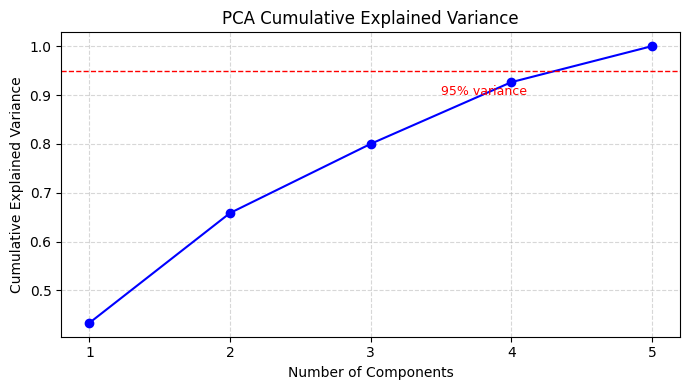

In [ ]:
# PCA with all components
pca_full = PCA()
pca_full.fit(X_scaled)

# explained variance
explained_variance = pca_full.explained_variance_ratio_
print("Explained variance ratio:", explained_variance)
print("Total variance retained:", np.sum(explained_variance))
plot_cumulative_variance(explained_variance, show_target=0.95)


- The first component explains ~32% of the total variance.
- The first three components together explain ~72% of the variance.
- Around 4 to 5 components are needed to reach 95% variance.

In [6]:
X_pca = pca_full.transform(X_scaled)   # shape (n_samples, n_features)
X_3d = X_pca[:, :3]                    # first 3 principal components

explained_variance = np.round(pca_full.explained_variance_ratio_, 3)
print("Explained variance ratio:", explained_variance)
print("Total variance retained by 3 PCs:", round(explained_variance[:3].sum(), 3))

Explained variance ratio: [0.433 0.225 0.142 0.126 0.074]
Total variance retained by 3 PCs: 0.8


In [7]:
print("\n Variance kept by first 3 PCs:", round(explained_variance[:3].sum(), 3))
plot_3d(X_3d, y, algorithm="PCA", target_name=TARGET_COL)


 Variance kept by first 3 PCs: 0.8


We can notice that component 1 is here the most important.

## t-SNE

In [8]:
tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate="auto",
    max_iter=1200,
    early_exaggeration=12.0,
    metric="cosine",
    init="pca",
    n_jobs=-1,
    angle=0.5,
    method="barnes_hut"
)
X_tsne = tsne.fit_transform(X)

In [9]:
plot_3d(X_tsne, y, algorithm="t-SNE", target_name=TARGET_COL)

## UMAP

In [10]:
# UMAP reducer
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=15,      # controls local/global structure balance
    min_dist=0.05,       # controls cluster compactness
    metric="cosine",
    n_jobs=-1
)

# Fit and transform
X_umap = reducer.fit_transform(X)

In [11]:
plot_3d(X_umap, y, algorithm="UMAP", target_name=TARGET_COL)

## MIX
1st component PCA, t-SNE, UMAP

In [12]:
pc1 = X_pca[:, 0]
tsne1 = X_tsne[:, 0]
umap1 = X_umap[:, 0]

X_combined = pd.DataFrame({
    "PCA_1": pc1,
    "tSNE_1": tsne1,
    "UMAP_1": umap1,
})

plot_3d(X_combined, y, algorithm="Mix for the 1st component", target_name=TARGET_COL)


In [13]:
df_mix = pd.concat([pd.DataFrame(X_combined, columns=X_combined.columns), pd.Series(y, name='DEATH_EVENT')], axis=1)
df_mix.to_csv('../data/df_mix.csv', index=False)

In [23]:
df = pd.read_csv('../data/df_clean.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582.0,0,20.0,1,265000.00,1.9,130.0,1,0,4.0,1
1,55.0,0,7861.0,0,38.0,0,263358.03,1.1,136.0,1,0,6.0,1
2,65.0,0,146.0,0,20.0,0,162000.00,1.3,129.0,1,1,7.0,1
3,50.0,1,111.0,0,20.0,0,210000.00,1.9,137.0,1,0,7.0,1
4,65.0,1,160.0,1,20.0,0,327000.00,2.7,116.0,0,0,8.0,1


In [24]:
from scripts.dimred.pipeline import build_preprocessing_pipeline

preprocessing_pipeline = build_preprocessing_pipeline()
df_prep = preprocessing_pipeline.fit_transform(df)

In [25]:
# drop target 
df_copy = df.copy()
TARGET_COL = 'DEATH_EVENT'

X = df_copy.drop(columns=[TARGET_COL])
y = df_copy[TARGET_COL]

cols_to_drop = ['high_blood_pressure', 'platelets', 'sex', 'creatinine_phosphokinase', 'anaemia', 'smoking', 'diabetes']
X = X.drop(columns=cols_to_drop)

X.shape

(299, 5)

PCA

In [30]:
# standarize data
scaler = StandardScaler()
X = scaler.fit_transform(X)

Explained variance ratio: [0.28939043 0.23080212 0.18032953 0.1515476  0.14793032]
Total variance retained: 0.9999999999999999


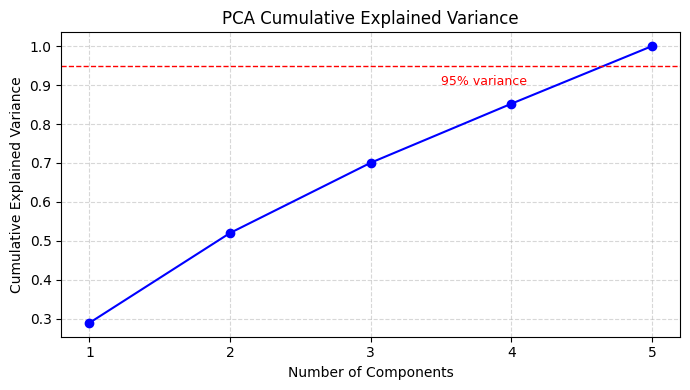

In [31]:
# PCA with all components
pca_full = PCA()
pca_full.fit(X)

# explained variance
explained_variance = pca_full.explained_variance_ratio_
print("Explained variance ratio:", explained_variance)
print("Total variance retained:", np.sum(explained_variance))
plot_cumulative_variance(explained_variance, show_target=0.95)


In [32]:
X_pca = pca_full.transform(X_scaled)   # shape (n_samples, n_features)
X_3d = X_pca[:, :3]                    # first 3 principal components

explained_variance = np.round(pca_full.explained_variance_ratio_, 3)
print("Explained variance ratio:", explained_variance)
print("Total variance retained by 3 PCs:", round(explained_variance[:3].sum(), 3))

Explained variance ratio: [0.289 0.231 0.18  0.152 0.148]
Total variance retained by 3 PCs: 0.7


In [33]:
print("\n Variance kept by first 3 PCs:", round(explained_variance[:3].sum(), 3))
plot_3d(X_3d, y, algorithm="PCA", target_name=TARGET_COL)


 Variance kept by first 3 PCs: 0.7


t-SNE

In [34]:
tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate="auto",
    max_iter=1200,
    early_exaggeration=12.0,
    metric="cosine",
    init="pca",
    n_jobs=-1,
    angle=0.5,
    method="barnes_hut"
)
X_tsne = tsne.fit_transform(X)

In [35]:
plot_3d(X_tsne, y, algorithm="t-SNE", target_name=TARGET_COL)

UMAP

In [36]:
# UMAP reducer
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=15,      # controls local/global structure balance
    min_dist=0.05,       # controls cluster compactness
    metric="cosine",
    n_jobs=-1
)

# Fit and transform
X_umap = reducer.fit_transform(X)

In [37]:
plot_3d(X_umap, y, algorithm="UMAP", target_name=TARGET_COL)

MIX

In [47]:
pc1 = X_pca[:, 0]
tsne1 = X_tsne[:, 0]
umap1 = X_umap[:, 0]

X_combined = pd.DataFrame({
    "PCA_1": pc1,
    "tSNE_1": tsne1,
    "UMAP_1": umap1,
})

plot_3d(X_combined, y, algorithm="Mix for the 1st component", target_name=TARGET_COL)


In [39]:
df_mix = pd.concat([pd.DataFrame(X_combined, columns=X_combined.columns), pd.Series(y, name='DEATH_EVENT')], axis=1)
df_mix.to_csv('../data/df_mix_2.csv', index=False)